In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo 
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier
from skorch import NeuralNetClassifier

### Data Fetching and Processing

In [2]:
try:
    dataset = fetch_ucirepo(id=350)
    X = dataset.data.features
    y = dataset.data.targets
    df = pd.concat([X, y], axis=1)
    df.columns = dataset.variables['description'].tolist()[1:]
    print("Sucessfully fetced dataset from ucirepo.")
except Exception as e:
    df = pd.read_csv('default_of_credit_card_clients.csv')
    print(f"Ucirepo failed: {e}. Uploaded data from local environment.")
    df.columns = df.iloc[0]
    df = df.iloc[1:].copy()

Sucessfully fetced dataset from ucirepo.


In [3]:
df = df.rename(columns={"default payment next month": "default"})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.reset_index(drop=True)

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Rows: 30,000   Columns: 24
Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Data Exploration

Class Distribution
  No Default (0) : 23,364  (77.88%)
  Default    (1) : 6,636  (22.12%)


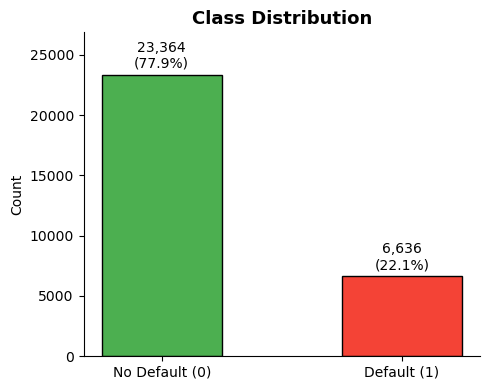

In [4]:
counts = df["default"].value_counts()
pcts   = df["default"].value_counts(normalize=True) * 100

print("Class Distribution")
print(f"  No Default (0) : {counts[0]:,}  ({pcts[0]:.2f}%)")
print(f"  Default    (1) : {counts[1]:,}  ({pcts[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["No Default (0)", "Default (1)"], counts,
              color=["#4CAF50", "#F44336"], edgecolor="black", width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig("output/class_distribution.png")
plt.show()

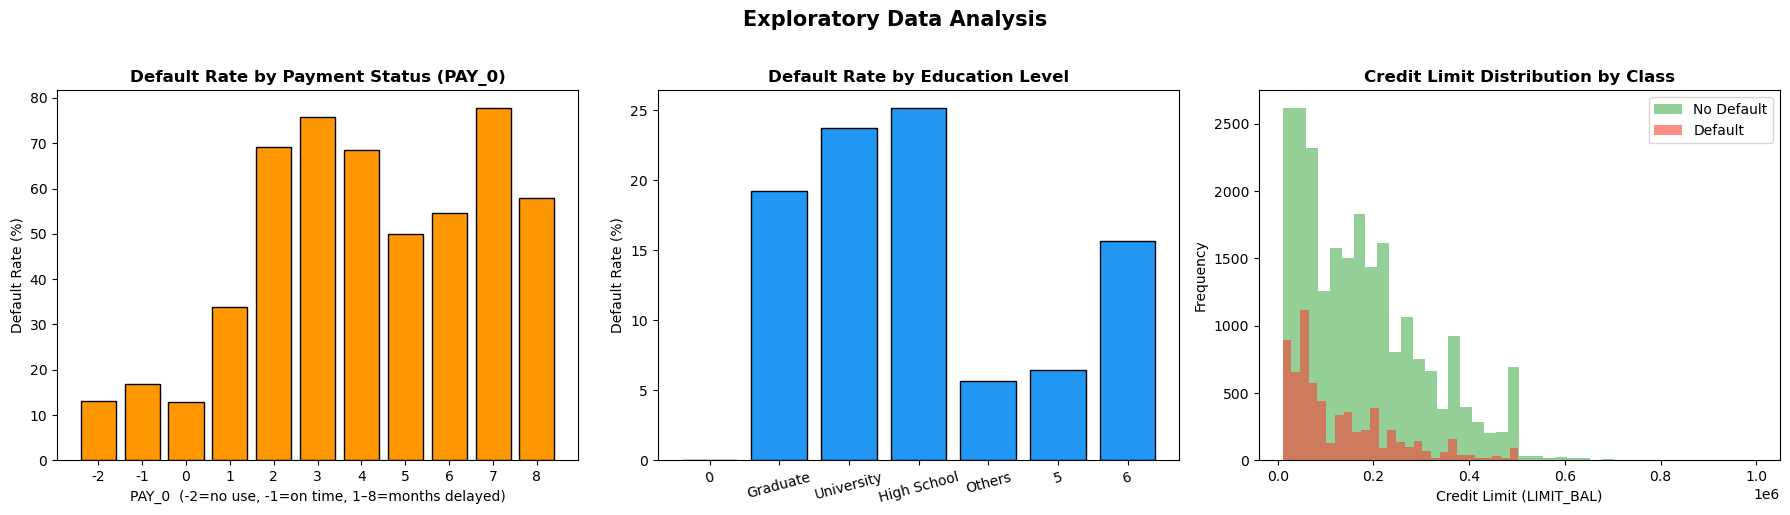

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pay_dr = df.groupby("PAY_0")["default"].mean() * 100
axes[0].bar(pay_dr.index.astype(str), pay_dr.values,
            color="#FF9800", edgecolor="black")
axes[0].set_title("Default Rate by Payment Status (PAY_0)", fontweight="bold")
axes[0].set_xlabel("PAY_0  (-2=no use, -1=on time, 1–8=months delayed)")
axes[0].set_ylabel("Default Rate (%)")

edu_labels = {1: "Graduate", 2: "University", 3: "High School", 4: "Others"}
edu_dr = df.groupby("EDUCATION")["default"].mean() * 100
edu_dr.index = [edu_labels.get(i, str(i)) for i in edu_dr.index]
axes[1].bar(edu_dr.index, edu_dr.values, color="#2196F3", edgecolor="black")
axes[1].set_title("Default Rate by Education Level", fontweight="bold")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

df[df["default"] == 0]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#4CAF50", label="No Default")
df[df["default"] == 1]["LIMIT_BAL"].plot(
    kind="hist", bins=40, alpha=0.6, ax=axes[2], color="#F44336", label="Default")
axes[2].set_title("Credit Limit Distribution by Class", fontweight="bold")
axes[2].set_xlabel("Credit Limit (LIMIT_BAL)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.suptitle("Exploratory Data Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/exploratory_data_analysis.png")
plt.show()

# Small Language Model (SLM)

#### Defining Feature Groups

In [6]:
STATIC_COLS = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
PAY_COLS = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]
BILL_COLS = ["BILL_AMT6", "BILL_AMT5", "BILL_AMT4", "BILL_AMT3", "BILL_AMT2", "BILL_AMT1"]
AMT_COLS = ["PAY_AMT6", "PAY_AMT5", "PAY_AMT4", "PAY_AMT3", "PAY_AMT2", "PAY_AMT1"]
TARGET_COL = "default"
NUMERIC_STATIC_COLS = ["LIMIT_BAL", "AGE"]
MONTHLY_NUMERIC_COLS = BILL_COLS + AMT_COLS + PAY_COLS

### Train-Test Split

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET_COL]
)

print(train_df.shape, test_df.shape)

(24000, 24) (6000, 24)


### Scaling Numerical Columns

In [8]:
scaler_static = StandardScaler()
scaler_monthly = StandardScaler()

train_df = train_df.copy()
test_df = test_df.copy()

train_df[NUMERIC_STATIC_COLS] = scaler_static.fit_transform(train_df[NUMERIC_STATIC_COLS])
test_df[NUMERIC_STATIC_COLS] = scaler_static.transform(test_df[NUMERIC_STATIC_COLS])

train_df[MONTHLY_NUMERIC_COLS] = scaler_monthly.fit_transform(train_df[MONTHLY_NUMERIC_COLS])
test_df[MONTHLY_NUMERIC_COLS] = scaler_monthly.transform(test_df[MONTHLY_NUMERIC_COLS])

### Dataset Construction and Token Preparation

In [9]:
class CreditDataset(Dataset):
    def __init__(self, X, y=None):
        if hasattr(X, 'reset_index'):
            self.X = X.reset_index(drop=True)
        else:
            self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if hasattr(self.X, 'iloc'):
            row = self.X.iloc[idx]
        else:
            row = self.X[idx]

        static_num = torch.tensor(
            [row["LIMIT_BAL"], row["AGE"]],
            dtype=torch.float32
        )

        static_cat = torch.tensor(
            [int(row["SEX"]), int(row["EDUCATION"]), int(row["MARRIAGE"])],
            dtype=torch.long
        )

        monthly_num = []
        monthly_pay = []

        for p, b, a in zip(PAY_COLS, BILL_COLS, AMT_COLS):
            monthly_num.append([row[b], row[a]])
            monthly_pay.append(int(row[p]) + 2)

        monthly_num = torch.tensor(monthly_num, dtype=torch.float32)
        monthly_pay = torch.tensor(monthly_pay, dtype=torch.long)

        X_dict = {
            "static_num": static_num,
            "static_cat": static_cat,
            "monthly_num": monthly_num,
            "monthly_pay": monthly_pay
        }
        
        if self.y is not None:
            val = self.y.iloc[idx] if hasattr(self.y, 'iloc') else self.y[idx]
            target = torch.tensor(val, dtype=torch.float32)
        else:
            target = torch.tensor(0.0, dtype=torch.float32)

        return X_dict, target

In [10]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

### Batch Structure Verification

In [11]:
batch = next(iter(train_loader))
inputs_dict, targets = batch
for k, v in inputs_dict.items():
    print(f"{k:12} : {v.shape}")
print(f"{'target':12} : {targets.shape}")

static_num   : torch.Size([128, 2])
static_cat   : torch.Size([128, 3])
monthly_num  : torch.Size([128, 6, 2])
monthly_pay  : torch.Size([128, 6])
target       : torch.Size([128])


### Positional Encoding

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

### Multi Head Self-Attention Mechanism

In [13]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout = 0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = self.dropout(torch.softmax(scores, dim=-1))
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        out = self.W_o(context)

        return out, attn_weights

### Transformer Block Architecture

In [14]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout = 0.1):
        super().__init__()

        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + self.dropout1(attn_out)

        ff_out = self.ff(self.norm2(x))
        x = x + self.dropout2(ff_out)

        return x, attn_weights

### Token Embedding and Transformation

In [16]:
class CreditTokenEmbedding(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        
        self.sex_emb = nn.Embedding(4, d_model)
        self.education_emb = nn.Embedding(8, d_model)
        self.marriage_emb = nn.Embedding(5, d_model)

        self.static_num_proj = nn.Linear(2, d_model)
        self.static_fusion = nn.Linear(d_model, d_model)

        self.monthly_num_proj = nn.Linear(2, d_model)
        self.pay_status_emb = nn.Embedding(16, d_model)

        self.dropout = nn.Dropout(0.1)

    def forward(self, static_num, static_cat, monthly_num, monthly_pay):
        batch_size = static_num.size(0)

        cls_token = self.cls_token.expand(batch_size, -1, -1)
        
        static_num_vec = self.static_num_proj(static_num)
        sex_vec = self.sex_emb(static_cat[:, 0])
        edu_vec = self.education_emb(static_cat[:, 1])
        marriage_vec = self.marriage_emb(static_cat[:, 2])

        static_token = static_num_vec + sex_vec + edu_vec + marriage_vec
        static_token = self.static_fusion(static_token).unsqueeze(1)

        monthly_num_vec = self.monthly_num_proj(monthly_num)
        pay_vec = self.pay_status_emb(monthly_pay)

        monthly_tokens = monthly_num_vec + pay_vec

        tokens = torch.cat([cls_token, static_token, monthly_tokens], dim=1)
        return self.dropout(tokens)

In [17]:
class TemporalTransformer(nn.Module):
    def __init__(self, d_model = 64, n_heads = 4, n_layers = 2, d_ff = 128, dropout = 0.1):
        super().__init__()

        self.token_embedding = CreditTokenEmbedding(d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=8)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.token_embedding.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=0.02)

    def forward(self, static_num, static_cat, monthly_num, monthly_pay):
        x = self.token_embedding(static_num, static_cat, monthly_num, monthly_pay)
        x = self.pos_enc(x)

        for block in self.blocks:
            x, _ = block(x)

        x = self.final_norm(x)
        logits = self.classifier(x[:, 0, :]).squeeze(-1)

        return logits
        
    def get_attention_maps(self, static_num, static_cat, monthly_num, monthly_pay):
        self.eval()
        with torch.no_grad():
            x = self.token_embedding(static_num, static_cat, monthly_num, monthly_pay)
            x = self.pos_enc(x)
            
            attn_maps = []
            for block in self.blocks:
                x, attn_w = block(x)
                attn_maps.append(attn_w)
            
            return attn_maps

### Model Training and Tuning

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [19]:
torch.manual_seed(42)

net = NeuralNetClassifier(
    TemporalTransformer,
    dataset=CreditDataset,
    module__d_model=64,
    module__n_heads=4,
    criterion=nn.BCEWithLogitsLoss,
    optimizer=optim.Adam,
    lr=0.001,
    max_epochs=20,
    batch_size=32,
    device=device,
    train_split=None
)

param_grid = {
        "module__d_model" : [32, 64],
        "module__n_heads" : [2, 4],
        "module__n_layers": [2, 3],
        "module__d_ff"    : [64, 128],
        "module__dropout" : [0.1, 0.2],
        "lr"              : [0.001, 0.0001],
        "criterion__pos_weight": [torch.tensor([3.0]).to(device), torch.tensor([4.0]).to(device)]
}

X_df = train_df.drop(columns=[TARGET_COL])
y_series = train_df[TARGET_COL].values.astype('float32')

grid = GridSearchCV(net, param_grid, cv=3, scoring='f1_macro')
grid.fit(X_df, y_series)

print(f"Best Score: {grid.best_score_}")
print(f"Best Params: {grid.best_params_}")

  epoch    train_loss      dur
-------  ------------  -------
      1        0.9056  11.9086
      2        0.8404  11.7478
      3        0.8288  11.5811
      4        0.8279  13.1794
      5        0.8238  12.6084
      6        0.8219  12.4781
      7        0.8189  11.3535
      8        0.8167  11.4254
      9        0.8157  11.2534
     10        0.8151  12.2252
     11        0.8146  11.6288
     12        0.8126  12.1863
     13        0.8079  12.3513
     14        0.8140  11.4737
     15        0.8074  11.6529
     16        0.8096  11.5251
     17        0.8099  11.0334
     18        0.8064  11.3059
     19        0.8079  11.4298
     20        0.8081  11.4711
  epoch    train_loss      dur
-------  ------------  -------
      1        0.9025  11.6867
      2        0.8324  11.8712
      3        0.8252  12.0863
      4        0.8214  11.3980
      5        0.8156  11.4292
      6        0.8152  11.6111
      7        0.8094  11.5932
      8        0.8077  11.5684
      9 

### Final Result

In [22]:
y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]

y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

  No Default       0.87      0.85      0.86      4673
     Default       0.51      0.54      0.53      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.79      0.79      6000

ROC-AUC Score: 0.7748


In [23]:
# Conservative Prediction
custom_threshold = 0.3

y_pred_conservative = (y_probs > custom_threshold).astype(int)
print(classification_report(y_test, y_pred_conservative, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.91      0.49      0.64      4673
     Default       0.32      0.84      0.46      1327

    accuracy                           0.57      6000
   macro avg       0.62      0.67      0.55      6000
weighted avg       0.78      0.57      0.60      6000



In [24]:
grid.best_estimator_.save_params(f_params='output/SLM_model_weights.pt')

### Visualisation

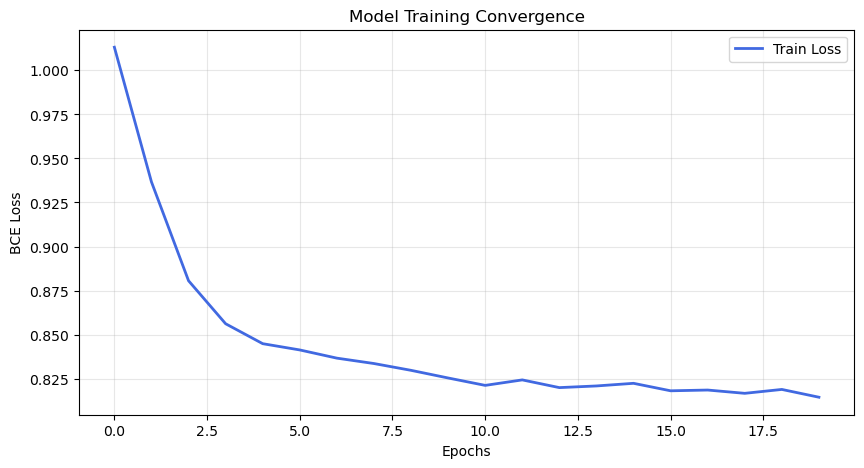

In [26]:
history = grid.best_estimator_.history

plt.figure(figsize=(10, 5))
plt.plot(history[:, 'train_loss'], label='Train Loss', color='royalblue', lw=2)
plt.title('Model Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("output/SLM_loss.png")
plt.show()

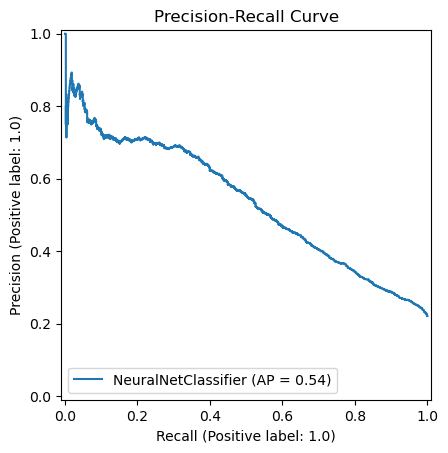

In [27]:
PrecisionRecallDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
plt.title('Precision-Recall Curve')
plt.savefig("output/SLM_precision_recall.png")
plt.show()

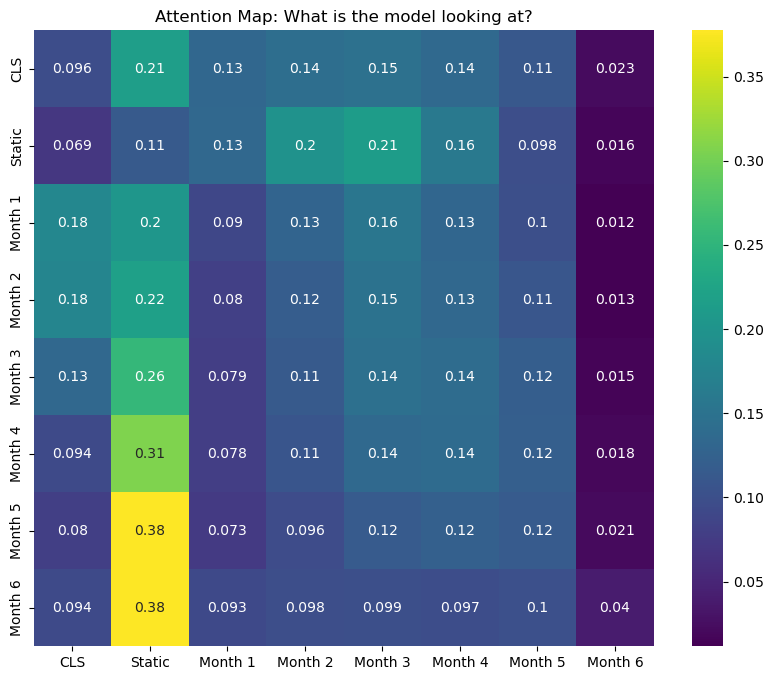

In [29]:
batch = next(iter(test_loader))
inputs_dict, _ = batch
device = grid.best_estimator_.device

s_num = inputs_dict['static_num'].to(device)
s_cat = inputs_dict['static_cat'].to(device)
m_num = inputs_dict['monthly_num'].to(device)
m_pay = inputs_dict['monthly_pay'].to(device)

attn_weights = grid.best_estimator_.module_.get_attention_maps(s_num, s_cat, m_num, m_pay)

heatmap_data = attn_weights[0][0, 0].detach().cpu().numpy()

labels = ['CLS', 'Static'] + [f'Month {i}' for i in range(1, 7)]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, xticklabels=labels, yticklabels=labels, cmap='viridis')
plt.title('Attention Map: What is the model looking at?')
plt.savefig("output/SLM_attention.png", bbox_inches='tight')
plt.show()

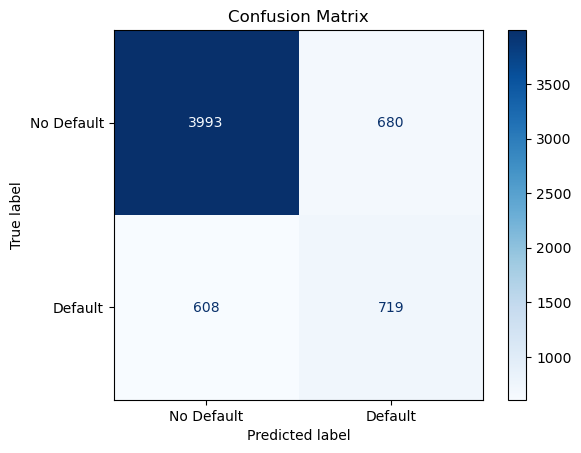

In [30]:
y_pred = grid.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig("output/SLM_confusion_matrix.png")
plt.show()

# Benchmark - Random Forest

### Using Raw Data

In [31]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

In [33]:
param_grid = {
    'n_estimators': [75, 100, 125],
    'max_depth': [15, 20, 25],
    'min_samples_split': [8, 10, 12]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train.values.ravel())

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

final_preds = best_rf.predict(X_test)

print("--- Final GridSearchCV Random Forest Report ---")
print(classification_report(y_test, final_preds))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': 25, 'min_samples_split': 12, 'n_estimators': 100}
Best CV Score (F1): 0.6845
--- Final GridSearchCV Random Forest Report ---
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [34]:
joblib.dump(grid_search.best_estimator_, 'output/raw_data_RF_model.joblib')

['output/raw_data_RF_model.joblib']

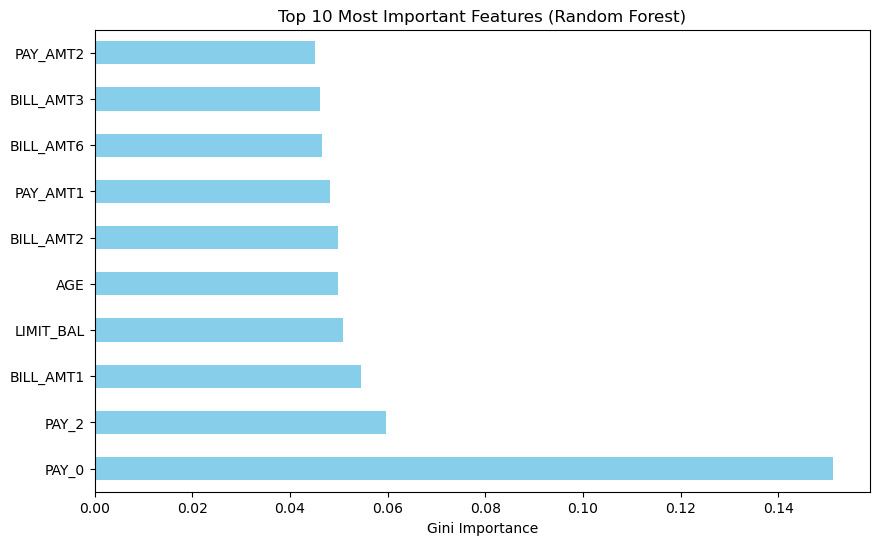

In [35]:
importances = best_rf.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Token_Dim_{i}' for i in range(len(importances))]

feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Gini Importance")
plt.savefig("output/raw_data_RF_feacture_importance.png")
plt.show()

### Using Tokenised Data

In [36]:
torch.manual_seed(42)

d_model = 64
tokeniser = CreditTokenEmbedding(d_model)
tokeniser.eval()

def get_tokens(dataloader):
    all_tokens = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, _ = batch
            tokens = tokeniser(
                inputs['static_num'],
                inputs['static_cat'],
                inputs['monthly_num'],
                inputs['monthly_pay']
            )
            flattened = tokens.view(tokens.size(0), -1)
            all_tokens.append(flattened.numpy())
            
    return np.concatenate(all_tokens, axis=0)

X_train_tokenised = get_tokens(train_loader)
X_test_tokenised = get_tokens(test_loader)

In [37]:
grid_search_tokenised = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_tokenised.fit(X_train_tokenised, y_train.values.ravel())

print(f"Best Parameters: {grid_search_tokenised.best_params_}")
print(f"Best CV Score (F1): {grid_search_tokenised.best_score_:.4f}")

best_rf_tokenised = grid_search_tokenised.best_estimator_

final_preds_tokenised = best_rf_tokenised.predict(X_test_tokenised)

print("--- Final GridSearchCV Random Forest Report ---")
print(classification_report(y_test, final_preds_tokenised))

Best Parameters: {'max_depth': 25, 'min_samples_split': 10, 'n_estimators': 75}
Best CV Score (F1): 0.4405
--- Final GridSearchCV Random Forest Report ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      4673
           1       0.09      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.43      0.50      0.44      6000
weighted avg       0.63      0.78      0.68      6000



In [38]:
joblib.dump(grid_search_tokenised.best_estimator_, 'output/tokenised_data_RF_model.joblib')

['output/tokenised_data_RF_model.joblib']

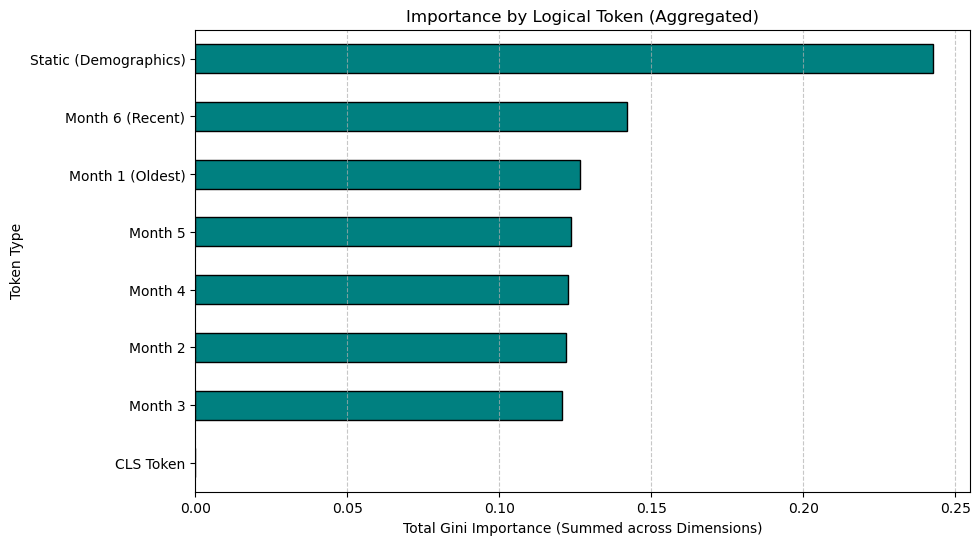

In [39]:
labels = [
    'CLS Token', 
    'Static (Demographics)', 
    'Month 1 (Oldest)', 
    'Month 2', 
    'Month 3', 
    'Month 4', 
    'Month 5', 
    'Month 6 (Recent)'
]

raw_importances = best_rf_tokenised.feature_importances_
aggregated_importance = []
for i in range(len(labels)):
    start_idx = i * d_model
    end_idx = (i + 1) * d_model
    token_sum = np.sum(raw_importances[start_idx:end_idx])
    aggregated_importance.append(token_sum)

token_importance_series = pd.Series(aggregated_importance, index=labels)
token_importance_series = token_importance_series.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
token_importance_series.plot(kind='barh', color='teal', edgecolor='black')
plt.title("Importance by Logical Token (Aggregated)")
plt.xlabel("Total Gini Importance (Summed across Dimensions)")
plt.ylabel("Token Type")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("output/tokenised_data_RF_feacture_importance.png")
plt.show()